# Corporate Credit Rating Prediction

## Project Overview

This project explores whether corporate financial characteristics can be used to predict credit ratings using machine learning.

The goal is to compare multiple classification models and evaluate how effectively they distinguish between different levels of corporate credit risk.

Models evaluated:
- Logistic Regression
- Random Forest
- Gradient Boosting

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving CCR_dataset to CCR_dataset


In [ ]:
import os

os.listdir()

['.config', 'CCR_dataset', 'sample_data']

In [ ]:
from scipy.io import arff
import pandas as pd

data, meta = arff.loadarff("CCR_dataset")
df = pd.DataFrame(data)

df.head()

,spid,rating,commeqta,llploans,costtoincome,roe,liqassta,size
0,141126.0,b'good',0.088445,0.057333,0.582160,0.177753,0.374932,18.818966
1,342066.0,b'average',0.055974,0.009640,0.526015,-0.122580,0.497892,19.072266
2,366790.0,b'outstanding',0.154322,0.014402,2.084550,-0.166647,0.087426,16.075995
3,146854.0,b'very_bad',0.026977,0.002951,0.248881,0.102982,0.457657,18.101099
4,319262.0,b'bad',0.096891,0.002645,0.544106,0.178183,0.148163,15.758143


In [ ]:
df["rating"] = df["rating"].str.decode("utf-8")

df.head()

,spid,rating,commeqta,llploans,costtoincome,roe,liqassta,size
0,141126.0,good,0.088445,0.057333,0.582160,0.177753,0.374932,18.818966
1,342066.0,average,0.055974,0.009640,0.526015,-0.122580,0.497892,19.072266
2,366790.0,outstanding,0.154322,0.014402,2.084550,-0.166647,0.087426,16.075995
3,146854.0,very_bad,0.026977,0.002951,0.248881,0.102982,0.457657,18.101099
4,319262.0,bad,0.096891,0.002645,0.544106,0.178183,0.148163,15.758143


In [ ]:
df.shape

(5000, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   spid          5000 non-null   float64
 1   rating        5000 non-null   object 
 2   commeqta      5000 non-null   float64
 3   llploans      5000 non-null   float64
 4   costtoincome  5000 non-null   float64
 5   roe           5000 non-null   float64
 6   liqassta      5000 non-null   float64
 7   size          5000 non-null   float64
dtypes: float64(7), object(1)
memory usage: 312.6+ KB


In [ ]:
df.isnull().sum()

,0
spid,0
rating,0
commeqta,0
llploans,0
costtoincome,0
roe,0
liqassta,0
size,0


In [ ]:
df["rating"].value_counts()

,count
rating,
good,500
average,500
outstanding,500
very_bad,500
bad,500
below_average,500
very_good,500
poor,500
excellent,500


## Data Inspection

Before building predictive models, I examined the dataset's structure, data types, missing values, and distribution of credit rating classes.

In [ ]:
df = df.drop(columns=["spid"])

df.head()

,rating,commeqta,llploans,costtoincome,roe,liqassta,size
0,good,0.088445,0.057333,0.582160,0.177753,0.374932,18.818966
1,average,0.055974,0.009640,0.526015,-0.122580,0.497892,19.072266
2,outstanding,0.154322,0.014402,2.084550,-0.166647,0.087426,16.075995
3,very_bad,0.026977,0.002951,0.248881,0.102982,0.457657,18.101099
4,bad,0.096891,0.002645,0.544106,0.178183,0.148163,15.758143


## Exploratory Data Analysis

I explored the financial variables to understand their distributions, relationships, and how they differ across credit rating categories before training predictive models.

In [ ]:
df.describe()

,commeqta,llploans,costtoincome,roe,liqassta,size
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.098667,0.019881,0.707218,0.072434,0.278848,17.666594
std,0.060603,0.020050,0.396710,0.136688,0.185743,1.901862
min,0.007804,-0.001574,0.051317,-0.495290,0.007040,10.652532
25%,0.054212,0.003987,0.469341,0.002513,0.129720,16.464669
50%,0.085571,0.012582,0.628569,0.085189,0.234405,17.798592
75%,0.133225,0.030034,0.791117,0.154354,0.404874,18.951919
max,0.317547,0.094904,2.465519,0.499487,0.815533,21.430289


In [ ]:
df.groupby("rating").mean()

,commeqta,llploans,costtoincome,roe,liqassta,size
rating,,,,,,
above_average,0.087127,0.047742,0.869896,-0.012485,0.424102,18.456604
average,0.090053,0.009089,0.690173,0.054626,0.364121,18.609178
bad,0.057911,0.003646,0.592275,0.139777,0.233581,18.387910
below_average,0.146309,0.035710,0.570748,0.080668,0.317805,18.240401
excellent,0.066718,0.021108,0.635265,0.101699,0.248671,17.337787
good,0.096847,0.030545,0.612404,0.154562,0.250780,17.594119
outstanding,0.108748,0.027643,1.524795,-0.028864,0.112625,16.371931
poor,0.092421,0.005555,0.458752,0.095894,0.268491,18.482072
very_bad,0.057003,0.001871,0.494334,0.083958,0.437552,18.605855


In [ ]:
df.corr(numeric_only=True)

,commeqta,llploans,costtoincome,roe,liqassta,size
commeqta,1.000000,0.128883,0.040964,-0.060095,-0.167989,-0.282857
llploans,0.128883,1.000000,0.220135,-0.153925,0.029258,-0.038298
costtoincome,0.040964,0.220135,1.000000,-0.242114,-0.169836,-0.157063
roe,-0.060095,-0.153925,-0.242114,1.000000,-0.005442,0.072053
liqassta,-0.167989,0.029258,-0.169836,-0.005442,1.000000,0.294428
size,-0.282857,-0.038298,-0.157063,0.072053,0.294428,1.000000


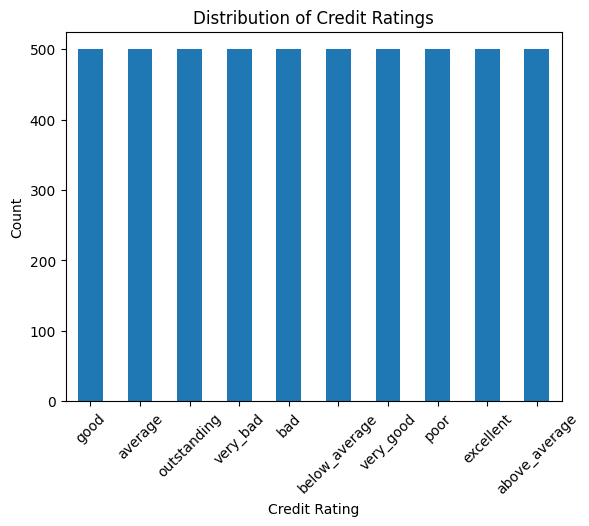

In [ ]:
import matplotlib.pyplot as plt

df["rating"].value_counts().plot(kind="bar")

plt.title("Distribution of Credit Ratings")
plt.xlabel("Credit Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

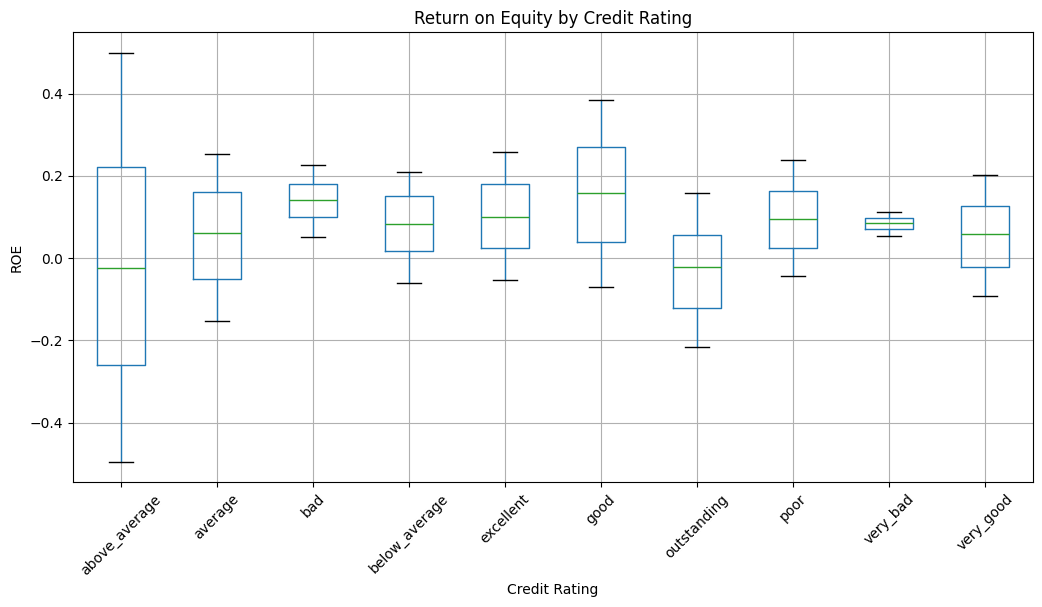

In [ ]:
df.boxplot(column="roe", by="rating", figsize=(12, 6))

plt.title("Return on Equity by Credit Rating")
plt.suptitle("")
plt.xlabel("Credit Rating")
plt.ylabel("ROE")
plt.xticks(rotation=45)

plt.show()

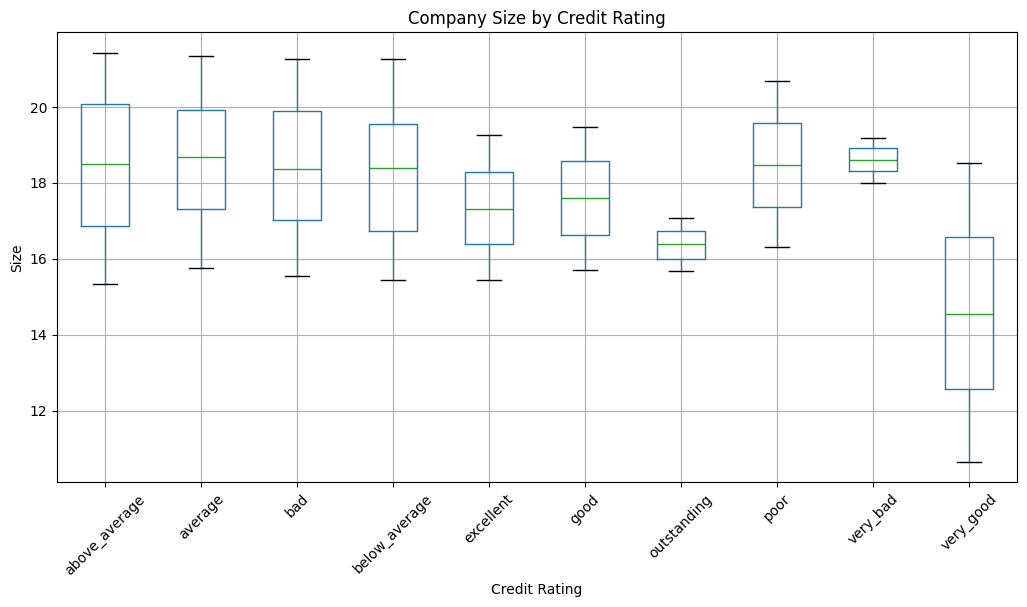

In [ ]:
df.boxplot(column="size", by="rating", figsize=(12, 6))

plt.title("Company Size by Credit Rating")
plt.suptitle("")
plt.xlabel("Credit Rating")
plt.ylabel("Size")
plt.xticks(rotation=45)

plt.show()

### Observation

Company size varies across credit rating categories, suggesting that size may provide useful predictive information. However, several rating classes have overlapping distributions, indicating that company size alone is unlikely to distinguish credit ratings reliably.

## Model Preparation

The dataset was separated into predictor variables and a target variable. The data was then split into training and testing sets so model performance could be evaluated on unseen observations.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["rating"])
y = df["rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (4000, 6)
Testing set: (1000, 6)


## Logistic Regression Baseline Model

I first trained a logistic regression model as a baseline. Logistic regression provides an interpretable starting point for comparing more complex machine learning models.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=2000))
])

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", accuracy)
print()
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Accuracy: 0.581

               precision    recall  f1-score   support

above_average       0.58      0.49      0.53       100
      average       0.45      0.41      0.43       100
          bad       0.48      0.62      0.54       100
below_average       0.57      0.53      0.55       100
    excellent       0.46      0.37      0.41       100
         good       0.41      0.39      0.40       100
  outstanding       0.87      0.90      0.88       100
         poor       0.53      0.55      0.54       100
     very_bad       0.65      0.77      0.70       100
    very_good       0.78      0.78      0.78       100

     accuracy                           0.58      1000
    macro avg       0.58      0.58      0.58      1000
 weighted avg       0.58      0.58      0.58      1000



In [ ]:
from sklearn.metrics import f1_score

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    average="macro"
)

print("Macro F1 Score:", logistic_f1)

Macro F1 Score: 0.5766368105761905


### Logistic Regression Results

The logistic regression baseline achieved 58.1% accuracy and a macro F1-score of approximately 0.58 across the 10 credit rating classes. Performance was strongest for more distinct categories such as `outstanding`, `very_good`, and `very_bad`, while several middle rating categories were more difficult to distinguish. This suggests that the financial features contain useful predictive signal, but a nonlinear model may capture more complex relationships between the variables.

## Random Forest Model

I trained a Random Forest classifier to test whether a nonlinear ensemble model could improve upon the logistic regression baseline by capturing more complex relationships between financial features and credit ratings.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average="macro")

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Macro F1:", rf_f1)
print()
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.79
Random Forest Macro F1: 0.7903949849275994

               precision    recall  f1-score   support

above_average       1.00      0.74      0.85       100
      average       0.72      0.71      0.71       100
          bad       0.84      0.95      0.89       100
below_average       0.80      0.66      0.73       100
    excellent       0.59      0.70      0.64       100
         good       0.63      0.56      0.59       100
  outstanding       0.91      0.95      0.93       100
         poor       0.64      0.83      0.72       100
     very_bad       0.96      1.00      0.98       100
    very_good       0.91      0.80      0.85       100

     accuracy                           0.79      1000
    macro avg       0.80      0.79      0.79      1000
 weighted avg       0.80      0.79      0.79      1000



In [ ]:
print("Logistic Regression Accuracy:", accuracy)
print("Logistic Regression Macro F1:", logistic_f1)
print()
print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Macro F1:", rf_f1)

Logistic Regression Accuracy: 0.581
Logistic Regression Macro F1: 0.5766368105761905

Random Forest Accuracy: 0.79
Random Forest Macro F1: 0.7903949849275994


### Random Forest Results

The Random Forest model substantially outperformed the logistic regression baseline, achieving 79.0% accuracy and a macro F1-score of approximately 0.79. This suggests that nonlinear relationships and interactions among the financial variables are important for distinguishing credit rating categories.

Performance was particularly strong for classes such as `very_bad`, `outstanding`, and `bad`, while several middle rating categories remained more difficult to classify accurately.

## Gradient Boosting Model

I trained a Gradient Boosting classifier as a third modeling approach to determine whether sequentially combining weak learners could improve predictive performance beyond logistic regression and Random Forest.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boost_model = GradientBoostingClassifier(
    random_state=42
)

gradient_boost_model.fit(X_train, y_train)

y_pred_gb = gradient_boost_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb, average="macro")

print("Gradient Boosting Accuracy:", gb_accuracy)
print("Gradient Boosting Macro F1:", gb_f1)
print()
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.807
Gradient Boosting Macro F1: 0.8068068735673151

               precision    recall  f1-score   support

above_average       0.99      0.81      0.89       100
      average       0.80      0.74      0.77       100
          bad       0.83      0.95      0.88       100
below_average       0.83      0.69      0.75       100
    excellent       0.62      0.74      0.68       100
         good       0.68      0.56      0.62       100
  outstanding       0.88      0.94      0.91       100
         poor       0.65      0.84      0.73       100
     very_bad       0.97      1.00      0.99       100
    very_good       0.91      0.80      0.85       100

     accuracy                           0.81      1000
    macro avg       0.82      0.81      0.81      1000
 weighted avg       0.82      0.81      0.81      1000



In [ ]:
print("MODEL COMPARISON")
print("-------------------------")

print("Logistic Regression")
print("Accuracy:", accuracy)
print("Macro F1:", logistic_f1)

print()

print("Random Forest")
print("Accuracy:", rf_accuracy)
print("Macro F1:", rf_f1)

print()

print("Gradient Boosting")
print("Accuracy:", gb_accuracy)
print("Macro F1:", gb_f1)

MODEL COMPARISON
-------------------------
Logistic Regression
Accuracy: 0.581
Macro F1: 0.5766368105761905

Random Forest
Accuracy: 0.79
Macro F1: 0.7903949849275994

Gradient Boosting
Accuracy: 0.807
Macro F1: 0.8068068735673151


### Model Comparison Results

Gradient Boosting achieved the strongest overall performance, with 80.7% accuracy and a macro F1-score of approximately 0.81. Random Forest performed similarly, reaching 79.0% accuracy and a macro F1-score of approximately 0.79.

Both ensemble models substantially outperformed the logistic regression baseline, suggesting that nonlinear relationships among the financial variables are important for predicting corporate credit ratings.

## Feature Importance

To better understand the model's predictions, I examined the importance of each financial variable in the Gradient Boosting model.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gradient_boost_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
1,llploans,0.244429
2,costtoincome,0.204972
5,size,0.199904
3,roe,0.167338
0,commeqta,0.094556
4,liqassta,0.088801


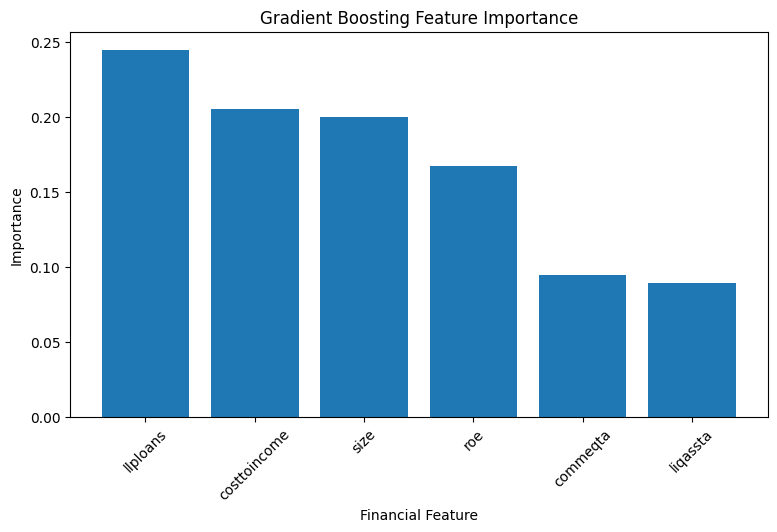

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Financial Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.show()

## Confusion Matrix

I examined the confusion matrix for the best-performing model to identify which credit rating categories were most frequently confused with one another.

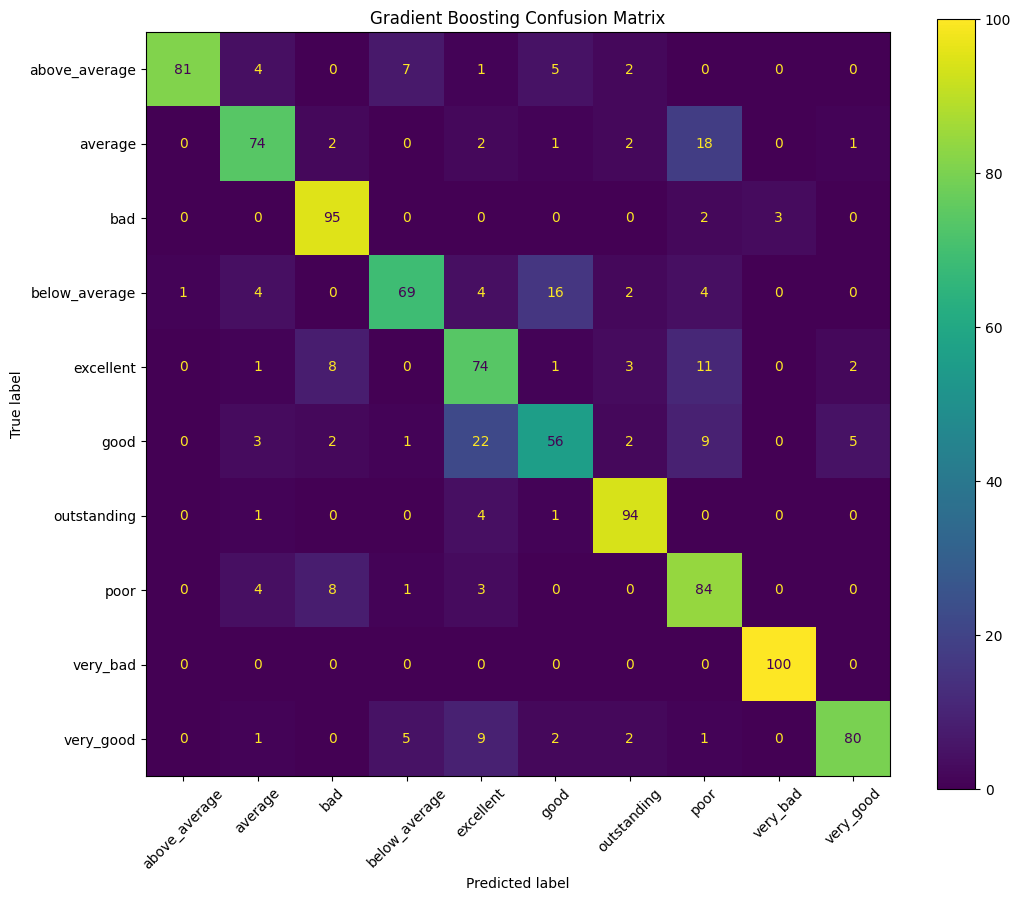

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred_gb,
    labels=gradient_boost_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=gradient_boost_model.classes_
)

fig, ax = plt.subplots(figsize=(12, 10))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Gradient Boosting Confusion Matrix")
plt.show()

## Model Performance Comparison

In [ ]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    "Macro F1": [
        logistic_f1,
        rf_f1,
        gb_f1
    ]
})

model_results

,Model,Accuracy,Macro F1
0,Logistic Regression,0.581,0.576637
1,Random Forest,0.790,0.790395
2,Gradient Boosting,0.807,0.806807


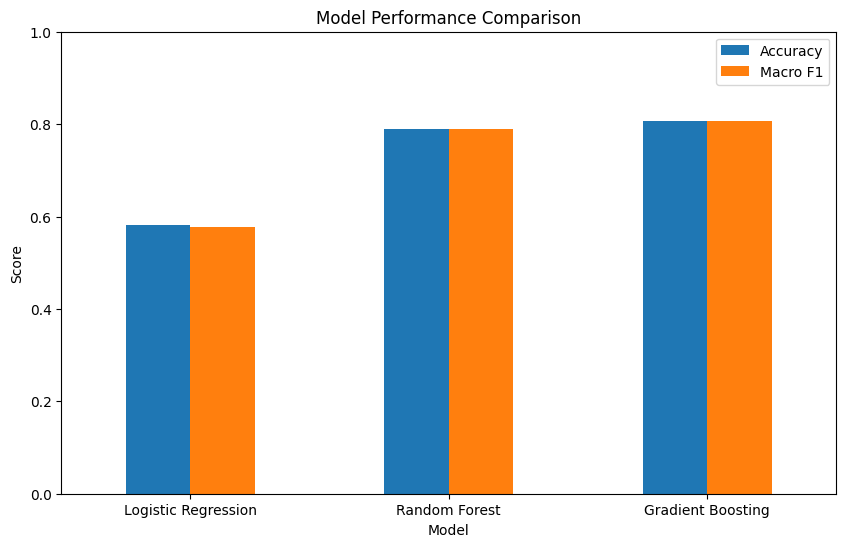

In [ ]:
model_results.set_index("Model")[["Accuracy", "Macro F1"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.show()

# Conclusion

This project evaluated whether financial characteristics could be used to predict corporate credit ratings across 10 rating categories.

Three classification approaches were compared: Logistic Regression, Random Forest, and Gradient Boosting. Logistic Regression established a baseline accuracy of 58.1%, while the nonlinear ensemble models performed substantially better.

Random Forest achieved 79.0% accuracy, while Gradient Boosting produced the strongest overall performance with 80.7% accuracy and a macro F1-score of approximately 0.81.

The improvement from logistic regression to the ensemble models suggests that the relationships between financial characteristics and credit ratings are not purely linear. Feature importance analysis was also used to identify which financial variables contributed most strongly to model predictions.

Overall, the results demonstrate that machine learning can capture meaningful relationships between corporate financial indicators and credit rating categories, although some neighboring rating classes remain more difficult to distinguish.